<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kesepuluh/blob/main/Praktikum_10_1_MG_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

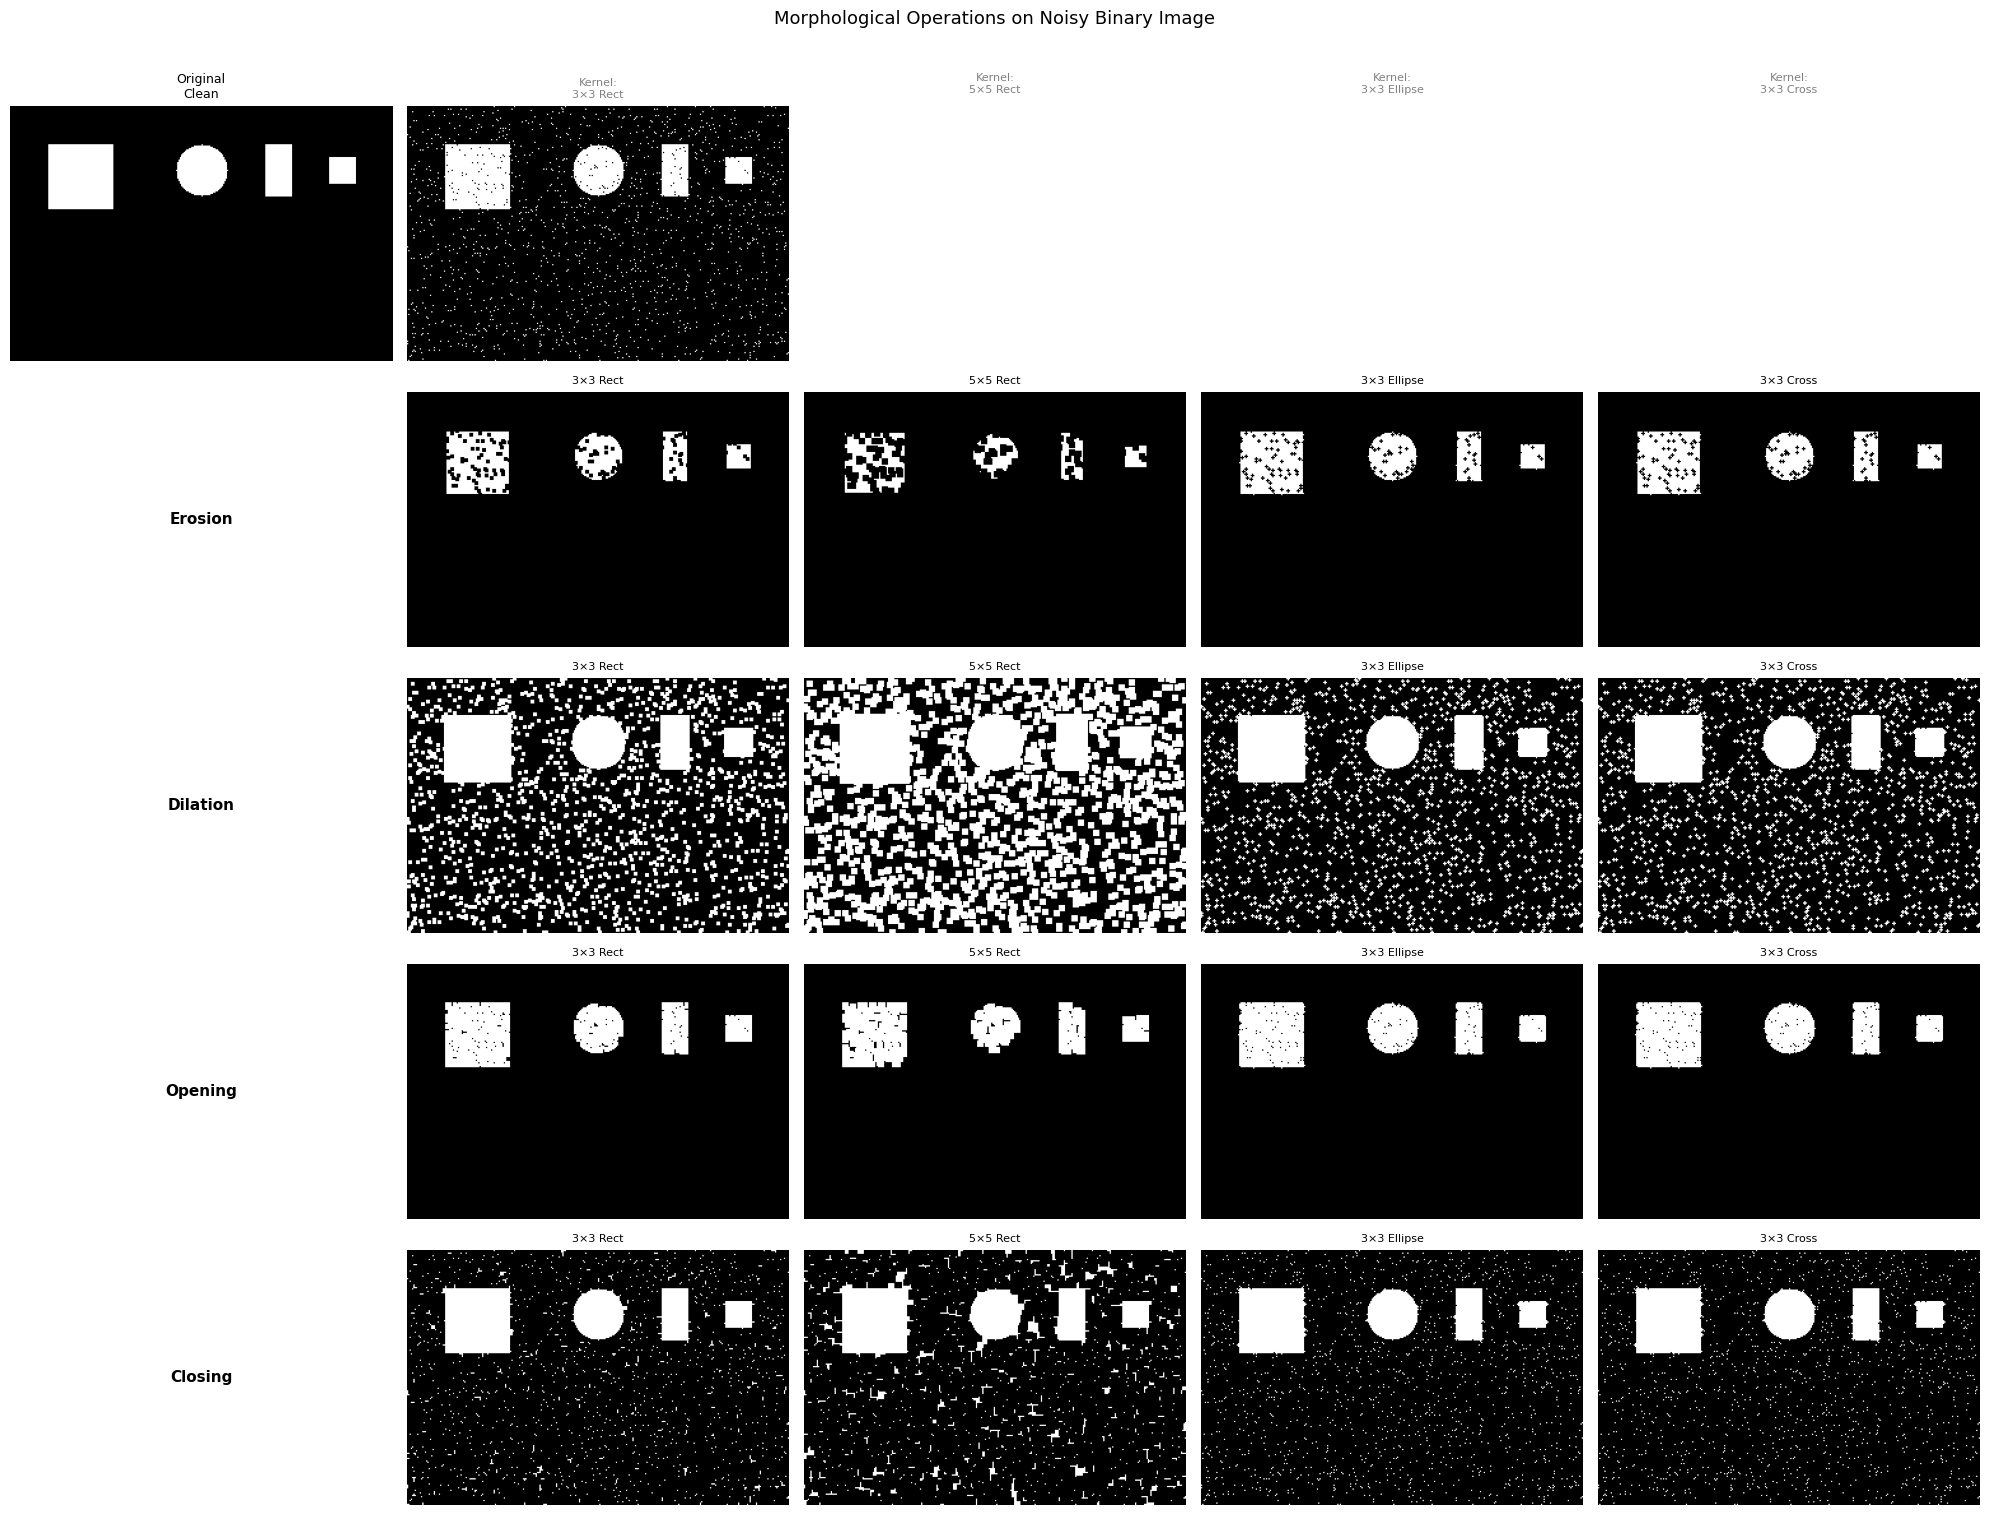

ANALYSIS OF MORPHOLOGICAL OPERATIONS

Original clean  — foreground pixels: 5160
Original noisy  — foreground pixels: 6396

Erosion:
  3×3 Rect       →  3637 px  (-1523 vs clean)
  5×5 Rect       →  2165 px  (-2995 vs clean)
  3×3 Ellipse    →  4101 px  (-1059 vs clean)
  3×3 Cross      →  4101 px  (-1059 vs clean)

Dilation:
  3×3 Rect       → 16844 px  (++11684 vs clean)
  5×5 Rect       → 31599 px  (++26439 vs clean)
  3×3 Ellipse    → 12035 px  (++6875 vs clean)
  3×3 Cross      → 12035 px  (++6875 vs clean)

Opening:
  3×3 Rect       →  4948 px  (-212 vs clean)
  5×5 Rect       →  4630 px  (-530 vs clean)
  3×3 Ellipse    →  4999 px  (-161 vs clean)
  3×3 Cross      →  4999 px  (-161 vs clean)

Closing:
  3×3 Rect       →  6807 px  (++1647 vs clean)
  5×5 Rect       →  8480 px  (++3320 vs clean)
  3×3 Ellipse    →  6556 px  (++1396 vs clean)
  3×3 Cross      →  6556 px  (++1396 vs clean)

PENJELASAN SINGKAT

1. Erosion
   • Menghilangkan noise kecil (salt noise)
   • Mengecilkan ob

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def latihan_1():
    # ─────────────────────────────────────────────
    # 1. Buat citra biner test pattern
    # ─────────────────────────────────────────────
    img = np.zeros((200, 300), dtype=np.uint8)

    cv2.rectangle(img, (30, 30),  (80, 80),  255, -1)   # Square
    cv2.circle   (img, (150, 50),  20,        255, -1)   # Circle
    cv2.rectangle(img, (200, 30), (220, 70), 255, -1)    # Vertical rectangle
    cv2.rectangle(img, (250, 40), (270, 60), 255, -1)    # Small rectangle

    # ─────────────────────────────────────────────
    # 2. Tambahkan salt-and-pepper noise
    # ─────────────────────────────────────────────
    rng = np.random.default_rng(seed=42)          # reproducible
    noise_mask = rng.random(img.shape) < 0.05

    img_noisy = img.copy()
    # Salt  : set ke 255 pada piksel genap (row+col even)
    # Pepper: set ke 0   pada piksel ganjil (row+col odd)
    coords = np.argwhere(noise_mask)
    for r, c in coords:
        img_noisy[r, c] = 255 if (r + c) % 2 == 0 else 0

    # ─────────────────────────────────────────────
    # 3. Structuring elements
    # ─────────────────────────────────────────────
    kernels = {
        '3×3 Rect'   : cv2.getStructuringElement(cv2.MORPH_RECT,    (3, 3)),
        '5×5 Rect'   : cv2.getStructuringElement(cv2.MORPH_RECT,    (5, 5)),
        '3×3 Ellipse': cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
        '3×3 Cross'  : cv2.getStructuringElement(cv2.MORPH_CROSS,   (3, 3)),
    }

    operations = {
        'Erosion' : lambda k: cv2.erode         (img_noisy, k, iterations=1),
        'Dilation': lambda k: cv2.dilate        (img_noisy, k, iterations=1),
        'Opening' : lambda k: cv2.morphologyEx  (img_noisy, cv2.MORPH_OPEN,  k),
        'Closing' : lambda k: cv2.morphologyEx  (img_noisy, cv2.MORPH_CLOSE, k),
    }

    # ─────────────────────────────────────────────
    # 4. Layout: (2 + len(operations)) baris × (1 + len(kernels)) kolom
    #
    #   Baris 0 : Original Clean | Original Noisy | kosong × n_kernels-1
    #   Baris 1+: op_name        | hasil per kernel
    # ─────────────────────────────────────────────
    n_ops     = len(operations)   # 4
    n_kernels = len(kernels)      # 4
    n_rows    = 1 + n_ops         # 5  (header + 4 operasi)
    n_cols    = 1 + n_kernels     # 5  (label + 4 kernel)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

    # ── Baris 0: original images ──────────────────
    axes[0, 0].imshow(img,       cmap='gray')
    axes[0, 0].set_title('Original\nClean',  fontsize=9)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_noisy, cmap='gray')
    axes[0, 1].set_title('Original\nNoisy',  fontsize=9)
    axes[0, 1].axis('off')

    for col in range(2, n_cols):
        axes[0, col].axis('off')

    # ── Baris 1-4: hasil operasi morfologi ────────
    kernel_names = list(kernels.keys())
    kernel_list  = list(kernels.values())

    for row_idx, (op_name, op_fn) in enumerate(operations.items(), start=1):
        # Kolom 0: label operasi
        axes[row_idx, 0].text(
            0.5, 0.5, op_name,
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            transform=axes[row_idx, 0].transAxes,
        )
        axes[row_idx, 0].axis('off')

        # Kolom 1-(n_kernels): hasil
        for col_idx, (k_name, kernel) in enumerate(zip(kernel_names, kernel_list), start=1):
            result = op_fn(kernel)
            axes[row_idx, col_idx].imshow(result, cmap='gray')
            axes[row_idx, col_idx].set_title(k_name, fontsize=8)
            axes[row_idx, col_idx].axis('off')

    # ── Header kolom kernel ───────────────────────
    for col_idx, k_name in enumerate(kernel_names, start=1):
        axes[0, col_idx].set_title(f'Kernel:\n{k_name}', fontsize=8, color='gray')
        axes[0, col_idx].axis('off')

    plt.suptitle('Morphological Operations on Noisy Binary Image', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('morphological_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ─────────────────────────────────────────────
    # 5. Analisis kuantitatif
    # ─────────────────────────────────────────────
    print("ANALYSIS OF MORPHOLOGICAL OPERATIONS")
    print("=" * 50)

    ref_pixels = int(np.sum(img > 0))
    print(f"\nOriginal clean  — foreground pixels: {ref_pixels}")
    print(f"Original noisy  — foreground pixels: {int(np.sum(img_noisy > 0))}")

    for op_name, op_fn in operations.items():
        print(f"\n{op_name}:")
        for k_name, kernel in kernels.items():
            result      = op_fn(kernel)
            fg_pixels   = int(np.sum(result > 0))
            diff        = fg_pixels - ref_pixels
            sign        = '+' if diff >= 0 else ''
            print(f"  {k_name:14s} → {fg_pixels:5d} px  ({sign}{diff:+d} vs clean)")

    print("\n" + "=" * 50)
    print("PENJELASAN SINGKAT")
    print("=" * 50)
    print("""
1. Erosion
   • Menghilangkan noise kecil (salt noise)
   • Mengecilkan objek
   • Dapat memisahkan objek yang menyatu

2. Dilation
   • Mengisi lubang kecil (pepper noise)
   • Membesarkan objek
   • Dapat menyambungkan objek terpisah

3. Opening  (Erosion → Dilation)
   • Menghilangkan noise tanpa mengubah ukuran objek secara signifikan
   • Efektif untuk noise removal / smoothing kontur

4. Closing  (Dilation → Erosion)
   • Mengisi lubang tanpa mengubah ukuran objek secara signifikan
   • Efektif untuk hole filling / menyambung celah kecil
""")


if __name__ == "__main__":
    latihan_1()